In [ ]:
#!pip install pandas numpy opencv-python matplotlib

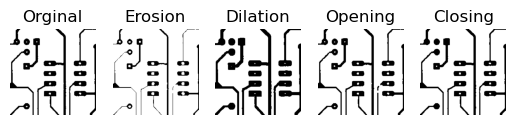

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

img = cv2.imread(r"C:\Users\soura\Documents\Sem 6 Labs\IPMV\Images\pcb_layout.gif")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, binary = cv2.threshold(gray, 127,255, cv2.THRESH_BINARY)

kernel = np.ones((3,3),np.uint8)

erosion = cv2.erode(binary, kernel, iterations=1)
dilation = cv2.dilate(binary, kernel, iterations=1)
opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
closing = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

titles=['Orginal', 'Erosion', 'Dilation', 'Opening', 'Closing']
images = [binary, erosion, dilation,opening,closing]
for i in range(5):
    plt.subplot(1,5,i+1)
    inv = cv2.bitwise_not(images[i])
    plt.imshow(inv, cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.show()
                        
    

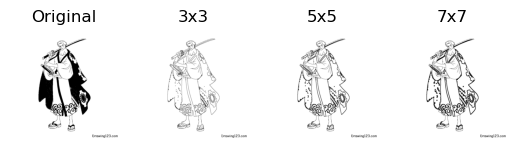

In [13]:
img_new = cv2.imread(r"C:\Users\soura\Documents\Sem 6 Labs\IPMV\Images\zoro.webp",0)

_, binary = cv2.threshold(img_new, 127,255, cv2.THRESH_BINARY)
def boundary(image, k):
    kernel = np.ones((k,k), np.uint8)
    erode = cv2.erode(image,kernel)
    return image - erode

_,binary = cv2.threshold(img_new, 127,255, cv2.THRESH_BINARY_INV)

b3 = boundary(binary,3)
b5 = boundary(binary,5)
b7 = boundary(binary,7)

titles = ['Original','3x3','5x5','7x7']
images = [binary,b3,b5,b7]

for i in range(4):
    plt.subplot(1,4,i+1)
    dis = cv2.bitwise_not(images[i])
    plt.imshow(dis, cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.show()
